In [1]:
import time
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import SGDOneClassSVM
from sklearn.pipeline import make_pipeline
from tabulate import tabulate

# from sklearn.neighbors import LocalOutlierFactor


plt.style.use("../auri.mplstyle")

pd.options.display.unicode.east_asian_width = True

In [2]:
parquet_path = Path("../data/processed/주건축물_검증규칙.parquet")
df_orig = pd.read_parquet(parquet_path)
print(f"Loaded shape: {df_orig.shape}")
df_orig.head()

Loaded shape: (7364967, 38)


,관리_건축물대장_PK,관리_상위_건축물대장_PK,단독,대지_위치,시군구_코드,법정동_코드,주_용도_코드,주_용도_코드_명,기타_용도,대지_면적(㎡),...,건폐율_재계산,건폐율_차이,기존19,용적률_재계산,용적률_차이,기존20,신규01,연면적_상한,신규02,신규03
0,10021950,10021363,False,서울특별시 종로구 숭인동 201번지,11110,17500,01000,단독주택,주택,NaN,...,NaN,NaN,None,NaN,NaN,None,None,NaN,None,False
1,10021957,10021366,False,서울특별시 종로구 숭인동 569번지,11110,17500,02000,공동주택,아파트,513.0,...,44.409357,-0.009357,False,128.625731,152.414269,True,False,2107.74,False,False
2,10021958,10021366,False,서울특별시 종로구 숭인동 569번지,11110,17500,02000,공동주택,연립주택,NaN,...,NaN,NaN,None,NaN,NaN,None,None,NaN,None,False
3,10021973,10021373,False,서울특별시 종로구 숭인동 1132번지,11110,17500,04000,제2종근린생활시설,영업,NaN,...,NaN,NaN,None,NaN,NaN,None,None,NaN,None,False
4,10021974,10021373,False,서울특별시 종로구 숭인동 1132번지,11110,17500,04000,제2종근린생활시설,근린생활시설,NaN,...,NaN,NaN,None,NaN,NaN,None,None,NaN,None,False


In [3]:
con = duckdb.connect(database=":memory:")
query = """
SELECT
  *,
FROM
  df_orig
WHERE
  COALESCE("대지_면적(㎡)", "총괄_대지_면적(㎡)", 0) 
    >= COALESCE("건축_면적(㎡)", 0)                             -- not 기존14
  AND COALESCE("연면적(㎡)", 0) >= COALESCE("건축_면적(㎡)", 0) -- not 기존16
  AND COALESCE("연면적(㎡)", 0)                                 -- not 신규01
        >= COALESCE("용적_률_산정_연면적(㎡)", 0)
  AND COALESCE("대지_면적(㎡)", "총괄_대지_면적(㎡)", 0) >= 0   -- not 신규03
  AND COALESCE("건축_면적(㎡)", "총괄_건축_면적(㎡)", 0) >= 0
  AND COALESCE("연면적(㎡)", 0) >= 0
  AND COALESCE("지상_층_수", 0) >= 0
  AND COALESCE("지하_층_수", 0) >= 0
;
"""
rel = con.sql(query)
con.sql("SELECT COUNT(*) FROM rel").show()

# 검증규칙 확실히 통과한 건축물만 선택
df_filtered = rel.df()
with pd.option_context("display.max_columns", None):
    print(tabulate(df_filtered.head(), headers="keys", tablefmt="psql"))

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│      5085645 │
└──────────────┘

+----+----------------------+---------------------------+--------+-----------------------------------+---------------+---------------+----------------+-------------------+--------------+-----------------+-----------------+--------------+--------------+---------------------------+--------------+-----------+--------------+--------------+---------------+----------------------+----------------------+-------------------+-------------------+--------------------------------+-------------------+---------------------+----------+----------+-----------------+---------------+----------+-----------------+---------------+----------+----------+---------------+----------+----------+
|    |   관리_건축물대장_PK |   관리_상위_건축물대장_PK | 단독   | 대지_위치                         |   시군구_코드 |   법정동_코드 |   주_용도_코드 | 주_용도_코드_명   | 기타_용도    |   대지_면적(㎡) |   건축_면적(㎡) |   건폐_율(%) |   연면적(㎡) |   용적_률_산정_연면적(㎡) |   용적_률(%) |  

In [4]:
df_filtered.shape

(5085645, 38)

In [5]:
df_filtered.dtypes

관리_건축물대장_PK               object
관리_상위_건축물대장_PK          object
단독                               bool
대지_위치                        object
시군구_코드                      object
법정동_코드                      object
주_용도_코드                     object
주_용도_코드_명                  object
기타_용도                        object
대지_면적(㎡)                   float64
건축_면적(㎡)                   float64
건폐_율(%)                      float64
연면적(㎡)                      float64
용적_률_산정_연면적(㎡)         float64
용적_률(%)                      float64
높이(m)                         float64
지상_층_수                        int32
지하_층_수                        int32
사용승인_일                      object
총괄_대지_면적(㎡)              float64
총괄_건축_면적(㎡)              float64
총괄_건폐_율(%)                 float64
총괄_연면적(㎡)                 float64
총괄_용적_률_산정_연면적(㎡)    float64
총괄_용적_률(%)                 float64
총괄_주_건축물_수               float64
기존14                          boolean
기존16                          boolean
건폐율_재계산                

### 무차원 변수 산출

건축물의 규모에 비례하지 않는(무차원) 개별 건축물의 특성을 반영하는 변수를 산출하기 위하여 면적 관련 변수의 차원 분석을 시행.

| 이름                 | 차원         |
| -------------------- | ------------ |
| 대지면적             | [면적]       |
| 건축면적             | [면적]       |
| 연면적               | [면적][층수] |
| 용적률 산정용 연면적 | [면적][층수] |
| 지상 층수            | [층수]       |

<!-- | 건폐율               | [면적]/[면적] = [비율]             |
| 용적률               | [면적][층수]/[면적] = [비율][층수] | -->
<!-- | 지하 층수            | [층수]                             | -->

물리학의 차원분석은 길이, 질량 등을 다루며, 개수, 비율 등은 무차원수로 보나, 건축물 대상 차원분석에서는 건축법에 따라 건축물의 특성을 통제하는 변수인 면적, 층수, 비율 등을 별도의 차원으로 두었음.

1차적으로 비율 변수를 산출한 후, 각 비율 변수의 상관관계를 검토한 후 비례 관계가 나타나지 않는 무차원 변수를 최종 산출하고, 클러스터링 및 기계학습에 활용.

| 이름            | 정의                          | 차원                               |
| --------------- | ----------------------------- | ---------------------------------- |
| 건폐율 (재산출) | 건축면적/대지면적             | [면적]/[면적] = [비율]             |
| 용적률 (재산출) | 용적률 산정용 연면적/대지면적 | [면적][층수]/[면적] = [비율][층수] |
| 지상 유효층수   | 용적률 산정용 연면적/건축면적 | [면적][층수]/[면적] = [비율][층수] |
| 용적 산정률     | 용적률 산정용 연면적/연면적   | [면적][층수]/[면적][층수] = [비율] |

<!-- | 실질 용적률     | 연면적/대지면적               | [면적][층수]/[면적] = [비율][층수] |
| 유효층수        | 연면적/건축면적               | [면적][층수]/[면적] = [비율][층수] | -->

용적률, 유효층수 등 연면적이 적용된 비율 변수를 층수로 나누어 층별 비율 변수를 도출.

| 이름            | 정의                                   | 차원                              |
| --------------- | -------------------------------------- | --------------------------------- |
| 지상층별 건폐율 | 용적률 산정용 연면적/지상층수/대지면적 | [면적][층수]/층수/[면적] = [비율] |
| 지상층별 충만률 | 용적률 산정용 연면적/지상층수/건축면적 | [면적][층수]/층수/[면적] = [비율] |


In [6]:
# 우선 COALESCE 적용
대지면적 = df_filtered["대지_면적(㎡)"].fillna(df_filtered["총괄_대지_면적(㎡)"])
# 건축면적 = df_filtered["건축_면적(㎡)"].fillna(df_filtered["총괄_건축_면적(㎡)"])
지상층수 = df_filtered["지상_층_수"].fillna(0)
지하층수 = df_filtered["지하_층_수"].fillna(0)
총층수 = 지상층수 + 지하층수

df_dimensionless = pd.DataFrame(
    {
        "관리_건축물대장_PK": df_filtered["관리_건축물대장_PK"],
        "대지면적": 대지면적,
        "건축면적": df_filtered["건축_면적(㎡)"],
        "연면적": df_filtered["연면적(㎡)"],
        "용적률_산정용_연면적": df_filtered["용적_률_산정_연면적(㎡)"],
        "지상층수": 지상층수,
        "건폐율": df_filtered["건축_면적(㎡)"] / 대지면적,
        "용적률": df_filtered["용적_률_산정_연면적(㎡)"] / 대지면적,
        # "실질_용적률": df_filtered["연면적(㎡)"] / 대지면적,
        # "유효층수": df_filtered["연면적(㎡)"] / df_filtered["건축_면적(㎡)"],
        "지상_유효층수": df_filtered["용적_률_산정_연면적(㎡)"]
        / df_filtered["건축_면적(㎡)"],
        "용적_산정률": df_filtered["용적_률_산정_연면적(㎡)"]
        / df_filtered["연면적(㎡)"],
        # "층별_건폐율": df_filtered["연면적(㎡)"] / 총층수 / 대지면적,
        "지상층별_건폐율": df_filtered["용적_률_산정_연면적(㎡)"] / 지상층수 / 대지면적,
        # "층별_충만률": df_filtered["연면적(㎡)"]
        # / 총층수
        # / df_filtered["건축_면적(㎡)"],
        "지상층별_충만률": df_filtered["용적_률_산정_연면적(㎡)"]
        / 지상층수
        / df_filtered["건축_면적(㎡)"],
    }
)

# 무한대/NaN 정리
df_dimensionless = df_dimensionless.replace(
    [pd.NA, float("inf"), -float("inf")], np.nan
)

In [7]:
df_dimensionless.dtypes

관리_건축물대장_PK       object
대지면적                float64
건축면적                float64
연면적                  float64
용적률_산정용_연면적    float64
지상층수                  int32
건폐율                  float64
용적률                  float64
지상_유효층수           float64
용적_산정률             float64
지상층별_건폐율         float64
지상층별_충만률         float64
dtype: object

In [8]:
df_dimensionless.head()

,관리_건축물대장_PK,대지면적,건축면적,연면적,용적률_산정용_연면적,지상층수,건폐율,용적률,지상_유효층수,용적_산정률,지상층별_건폐율,지상층별_충만률
0,10021950,NaN,NaN,29.75,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
1,10021957,513.0,227.82,1659.98,659.85,7,0.444094,1.286257,2.896366,0.397505,0.183751,0.413767
2,10021958,NaN,NaN,169.38,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN
3,10021973,NaN,NaN,44.33,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
4,10021974,NaN,NaN,36.26,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
with pd.option_context("display.float_format", "{:.4f}".format):
    display(df_dimensionless.describe())

,대지면적,건축면적,연면적,용적률_산정용_연면적,지상층수,건폐율,용적률,지상_유효층수,용적_산정률,지상층별_건폐율,지상층별_충만률
count,4827834.0000,4777956.0000,5081126.0000,4791078.0000,5085645.0000,4777956.0000,4724847.0000,4707543.0000,4791077.0000,4720271.0000,4703097.0000
mean,17015.6430,256.3988,815.2429,691.9291,2.3504,0.3080,0.6543,2.3107,0.9649,0.2739,0.9818
std,2346984.4250,1364.1303,60153.1923,38027.5603,3.1328,0.2223,3.1704,277.0266,0.0969,0.4277,56.2283
min,0.1200,0.0010,0.0010,-9.2400,0.0000,0.0000,-0.0280,0.0009,0.0001,-0.0093,0.0001
25%,244.4000,75.8500,85.9500,87.3800,1.0000,0.1188,0.1371,1.0000,1.0000,0.1078,0.8404
50%,495.0000,116.1300,178.8000,173.1000,1.0000,0.2521,0.3043,1.0000,1.0000,0.2278,1.0000
75%,1307.0000,199.5000,425.3100,404.4900,3.0000,0.5275,0.9516,2.0000,1.0000,0.4394,1.0000
max,4333333333.0000,2218284.2800,83374375.0000,58461732.0000,123.0000,1.0000,4946.7970,408459.3333,1.0000,549.6441,66603.0000


In [10]:
sampled = df_dimensionless.sample(n=3000, random_state=1106).copy()

In [11]:
sampled.head()

,관리_건축물대장_PK,대지면적,건축면적,연면적,용적률_산정용_연면적,지상층수,건폐율,용적률,지상_유효층수,용적_산정률,지상층별_건폐율,지상층별_충만률
1809318,11811100203070,249.0,87.69,98.34,98.34,2,0.352169,0.394940,1.121451,1.0,0.197470,0.560725
2781439,1264123536,986.0,91.32,182.64,182.64,2,0.092617,0.185233,2.000000,1.0,0.092617,1.000000
1979683,125213000029794,305.0,67.04,67.04,67.04,1,0.219803,0.219803,1.000000,1.0,0.219803,1.000000
4106746,115211000012263,535.0,80.41,80.41,80.41,1,0.150299,0.150299,1.000000,1.0,0.150299,1.000000
1100619,117612189,1319.0,112.60,112.60,112.60,1,0.085368,0.085368,1.000000,1.0,0.085368,1.000000


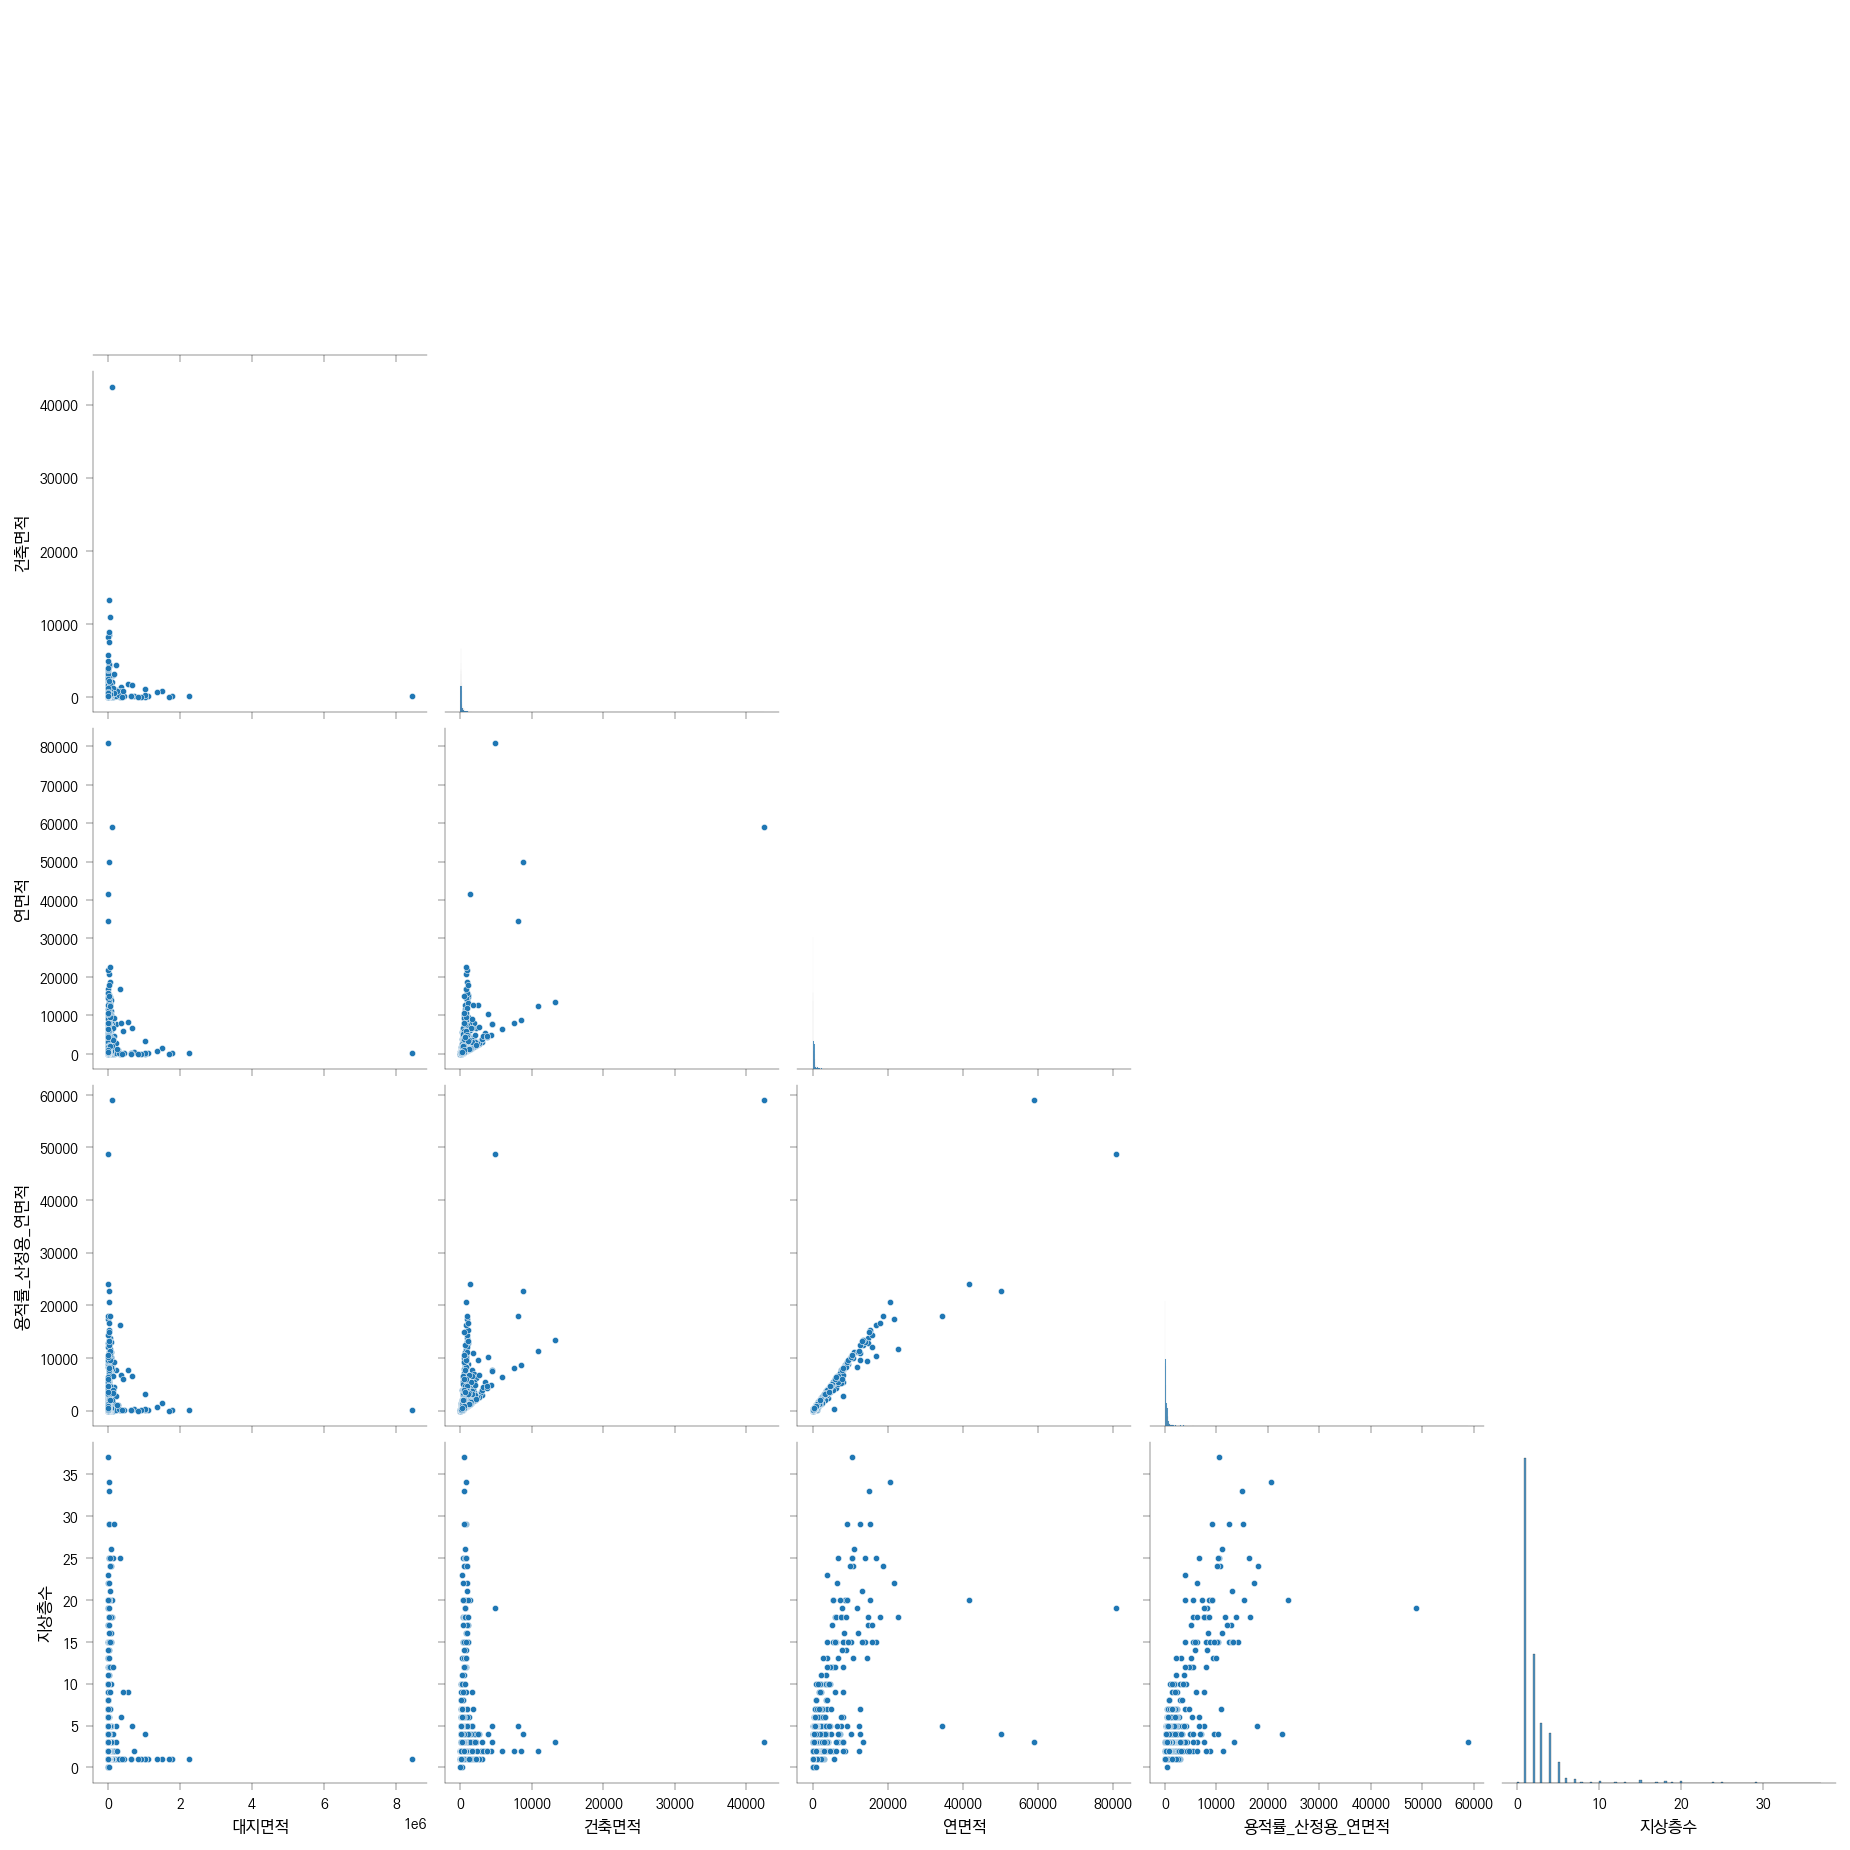

In [12]:
sns.pairplot(sampled.iloc[:, 1:6], corner=True)

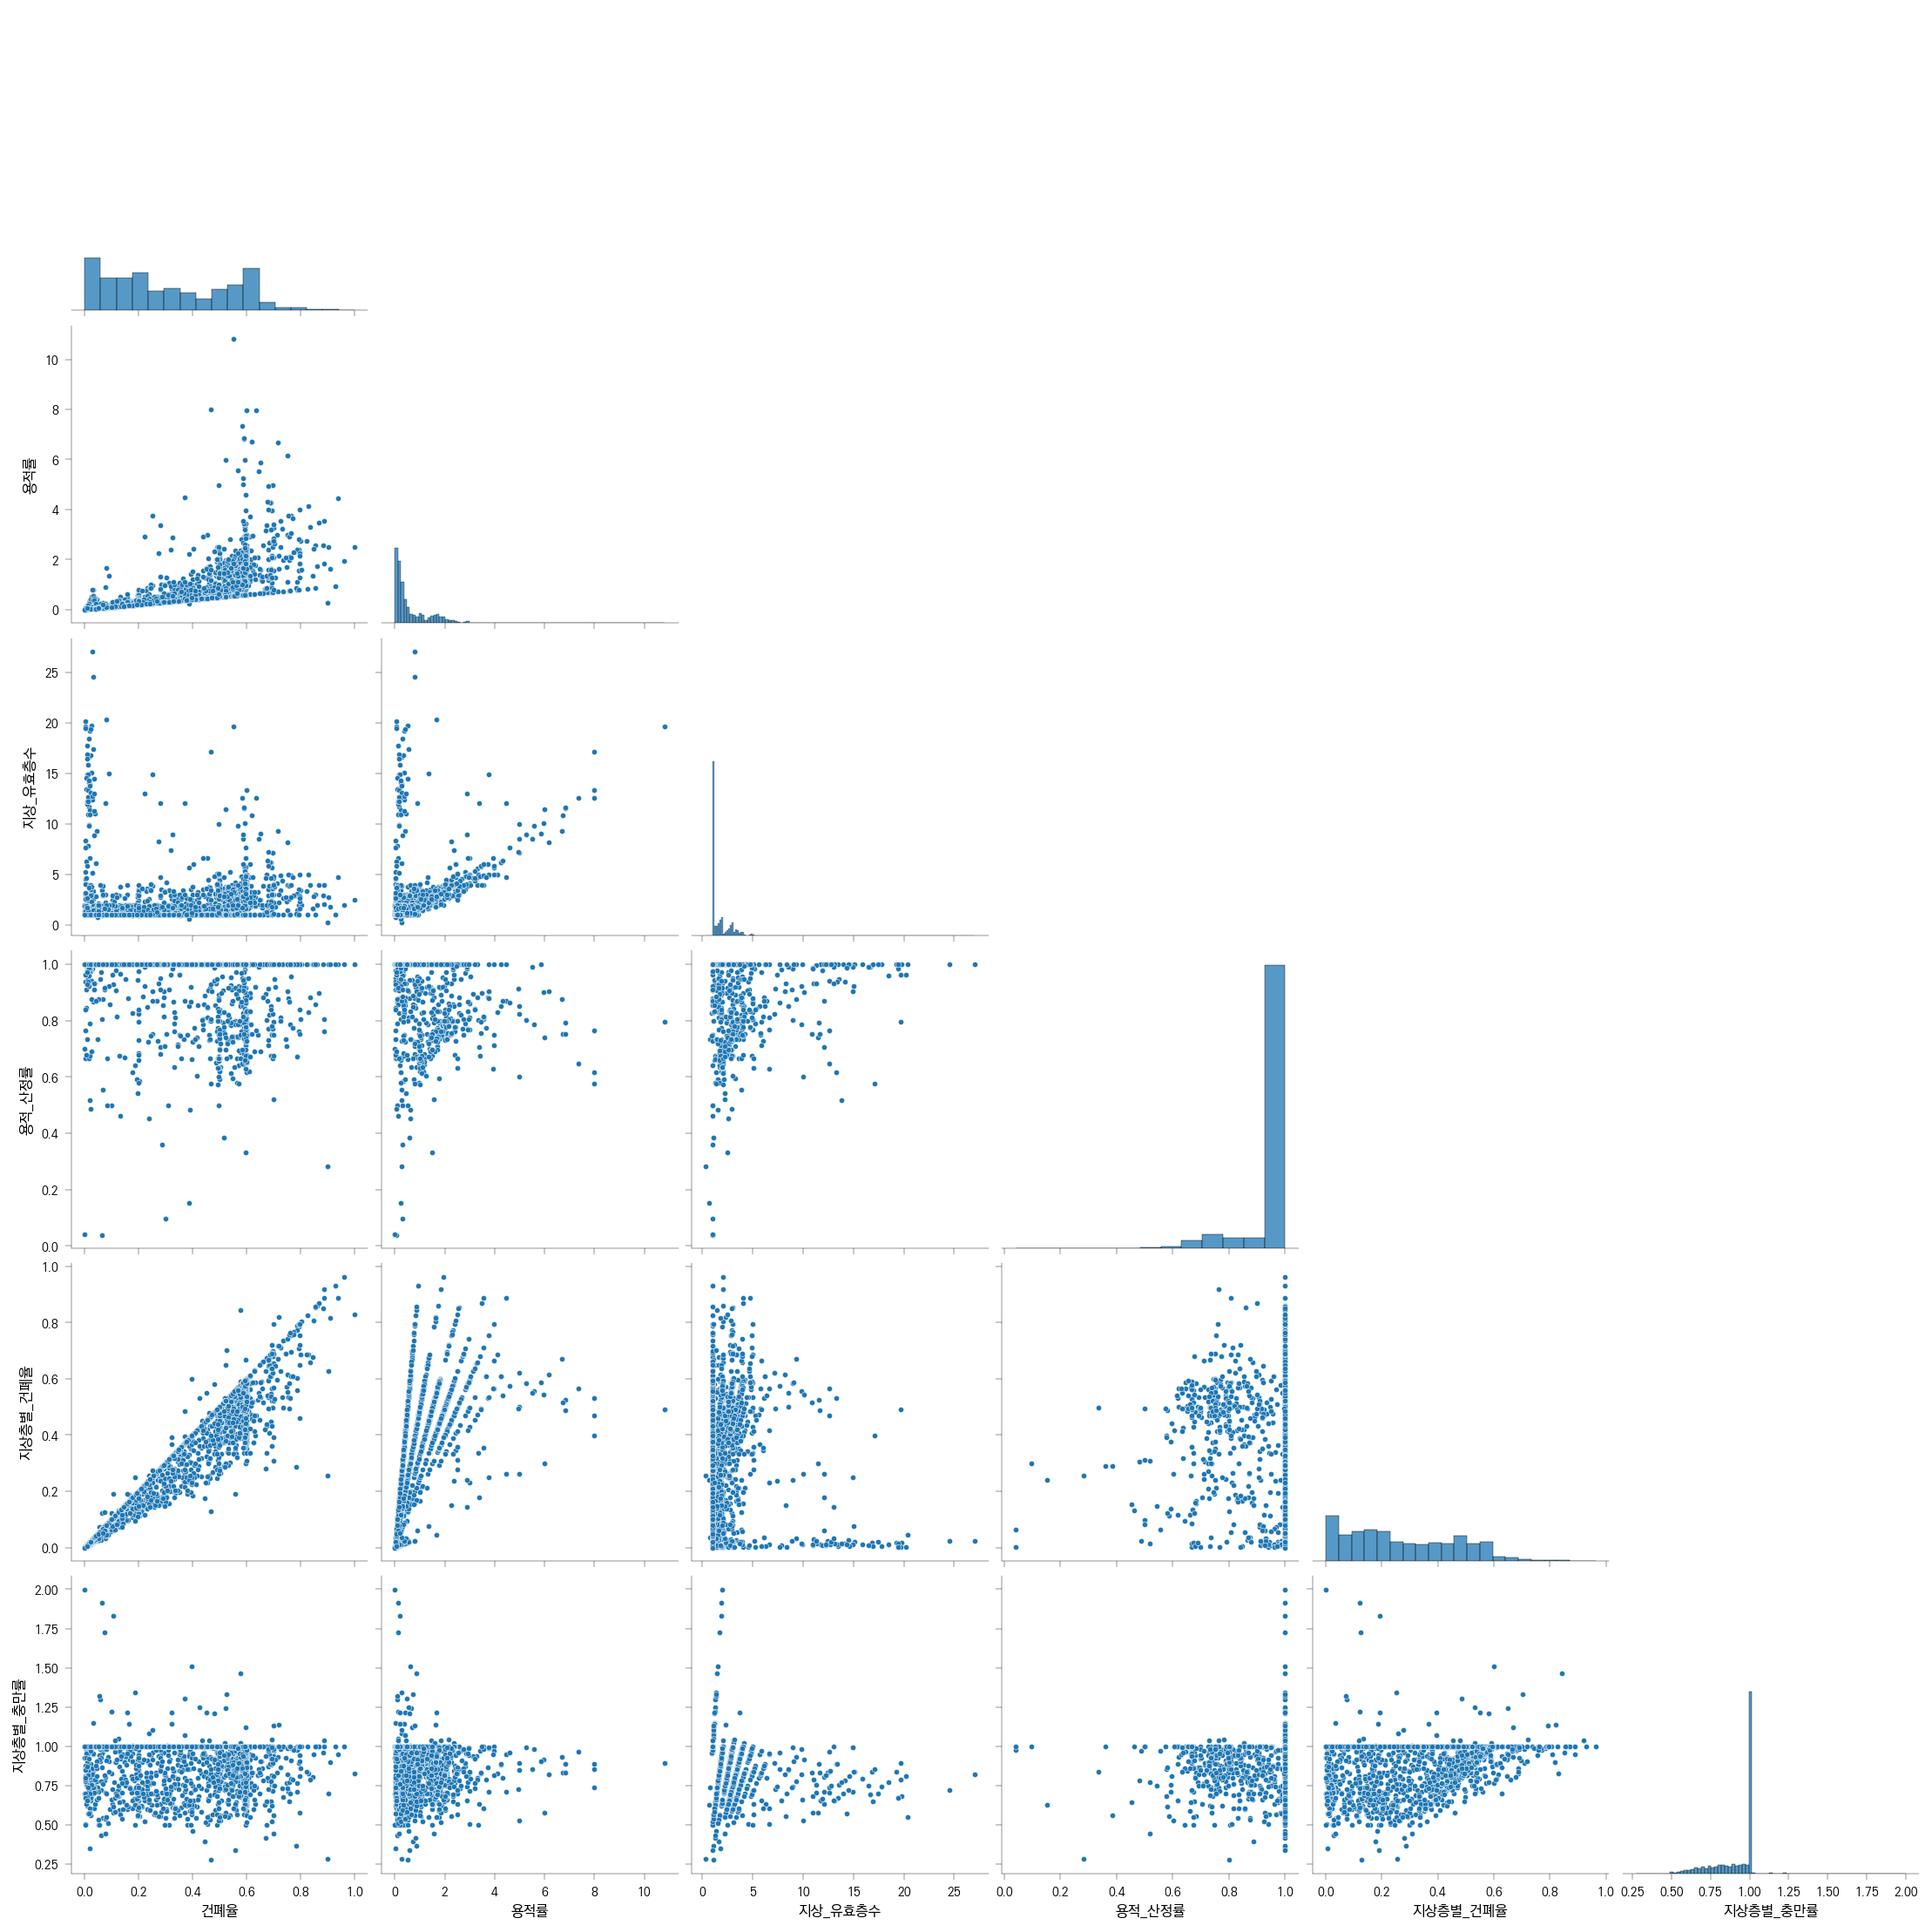

In [13]:
sns.pairplot(sampled.iloc[:, 6:], corner=True)

### Anormaly Detection

Isolation Forest, One-Class SVM using SGD


In [14]:
df = (
    df_dimensionless.iloc[:, 6:12]  # select only the dimensionless columns
    .dropna()
    # .sample(n=1_000_000, random_state=1106)
    .copy()
)

df.head()

,건폐율,용적률,지상_유효층수,용적_산정률,지상층별_건폐율,지상층별_충만률
1,0.444094,1.286257,2.896366,0.397505,0.183751,0.413767
7,0.206960,0.359377,1.736452,0.751080,0.179688,0.868226
9,0.178840,0.670265,3.747849,0.766531,0.167566,0.936962
10,0.193061,0.295801,1.532166,0.689246,0.147901,0.766083
11,0.203221,0.318606,1.567779,0.853811,0.159303,0.783889


In [15]:
df.shape

(4703097, 6)

In [16]:

# settings
outliers_fraction = 0.01

anomaly_algorithms = [
    (
        "One-Class SVM (SGD)",
        make_pipeline(
            Nystroem(gamma=0.1, random_state=1106, n_components=1_000),
            SGDOneClassSVM(
                nu=outliers_fraction,
                fit_intercept=True,
                random_state=1106,
            ),
        ),
    ),
    (
        "Isolation Forest",
        IsolationForest(contamination=outliers_fraction, random_state=1106),
    ),
]

# Choose sizes to test
sizes = [10_000, 100_000, 1_000_000]  # 4_703_097 failed on 64GB RAM machine
results = []

for algo_name, clf in anomaly_algorithms:
    for size in sizes:
        X = df.sample(n=size, random_state=1106).to_numpy()

        start = time.perf_counter()
        clf.fit(X)
        elapsed = time.perf_counter() - start

        results.append((size, elapsed))
        print(f"clf={algo_name} n={size:<6}  time={elapsed:.4f} sec")

clf=One-Class SVM (SGD) n=10000   time=0.6999 sec
clf=One-Class SVM (SGD) n=100000  time=3.2328 sec
clf=One-Class SVM (SGD) n=1000000  time=28.5738 sec
clf=Isolation Forest n=10000   time=0.1652 sec
clf=Isolation Forest n=100000  time=0.5582 sec
clf=Isolation Forest n=1000000  time=4.7528 sec


In [17]:
X = df.to_numpy()
X_sampled = df.sample(n=1_000_000, random_state=1106).to_numpy()

# settings
outliers_fraction = 0.01

In [18]:
clf = make_pipeline(
    Nystroem(gamma=0.1, random_state=1106, n_components=1_000),
    SGDOneClassSVM(
        nu=outliers_fraction,
        fit_intercept=True,
        random_state=1106,
    ),
)
clf.fit(X_sampled)
y_pred = clf.predict(X)
# align by index when assigning back
df_dimensionless["pred_one-class_svm"] = pd.Series(y_pred, index=df.index)

# runtime ~6 min.

In [19]:
clf = IsolationForest(contamination=outliers_fraction, random_state=1106)
clf.fit(X_sampled)
y_pred = clf.predict(X)

# align by index when assigning back
df_dimensionless["pred_isolation_forest"] = pd.Series(y_pred, index=df.index)

# runtime <1 min.

In [20]:
# 1: inlier, -1: outlier
df_dimensionless.head()

,관리_건축물대장_PK,대지면적,건축면적,연면적,용적률_산정용_연면적,지상층수,건폐율,용적률,지상_유효층수,용적_산정률,지상층별_건폐율,지상층별_충만률,pred_one-class_svm,pred_isolation_forest
0,10021950,NaN,NaN,29.75,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10021957,513.0,227.82,1659.98,659.85,7,0.444094,1.286257,2.896366,0.397505,0.183751,0.413767,1.0,-1.0
2,10021958,NaN,NaN,169.38,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10021973,NaN,NaN,44.33,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10021974,NaN,NaN,36.26,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
df_orig.loc[1]

관리_건축물대장_PK                                      10021957
관리_상위_건축물대장_PK                                 10021366
단독                                                       False
대지_위치                       서울특별시 종로구 숭인동 569번지
시군구_코드                                                11110
법정동_코드                                                17500
주_용도_코드                                               02000
주_용도_코드_명                                         공동주택
기타_용도                                                 아파트
대지_면적(㎡)                                              513.0
건축_면적(㎡)                                             227.82
건폐_율(%)                                                  44.4
연면적(㎡)                                               1659.98
용적_률_산정_연면적(㎡)                                   659.85
용적_률(%)                                                281.04
높이(m)                                                     20.6
지상_층_수                                                    

숭인동아파트(숭인모범) 아파트 한 동에 대해, SVM은 inlier로 IF는 outlier로 판정함.


In [22]:
with pd.option_context("display.float_format", "{:.4f}".format):
    display(df_dimensionless.describe())

,대지면적,건축면적,연면적,용적률_산정용_연면적,지상층수,건폐율,용적률,지상_유효층수,용적_산정률,지상층별_건폐율,지상층별_충만률,pred_one-class_svm,pred_isolation_forest
count,4827834.0000,4777956.0000,5081126.0000,4791078.0000,5085645.0000,4777956.0000,4724847.0000,4707543.0000,4791077.0000,4720271.0000,4703097.0000,4703097.0000,4703097.0000
mean,17015.6430,256.3988,815.2429,691.9291,2.3504,0.3080,0.6543,2.3107,0.9649,0.2739,0.9818,0.9800,0.9796
std,2346984.4250,1364.1303,60153.1923,38027.5603,3.1328,0.2223,3.1704,277.0266,0.0969,0.4277,56.2283,0.1988,0.2010
min,0.1200,0.0010,0.0010,-9.2400,0.0000,0.0000,-0.0280,0.0009,0.0001,-0.0093,0.0001,-1.0000,-1.0000
25%,244.4000,75.8500,85.9500,87.3800,1.0000,0.1188,0.1371,1.0000,1.0000,0.1078,0.8404,1.0000,1.0000
50%,495.0000,116.1300,178.8000,173.1000,1.0000,0.2521,0.3043,1.0000,1.0000,0.2278,1.0000,1.0000,1.0000
75%,1307.0000,199.5000,425.3100,404.4900,3.0000,0.5275,0.9516,2.0000,1.0000,0.4394,1.0000,1.0000,1.0000
max,4333333333.0000,2218284.2800,83374375.0000,58461732.0000,123.0000,1.0000,4946.7970,408459.3333,1.0000,549.6441,66603.0000,1.0000,1.0000


In [23]:
stat_func_names = ["count", "mean", "std", "min", "max"]

stats = df_dimensionless.groupby("pred_one-class_svm")[
    [
        "대지면적",
        "건축면적",
        "연면적",
        "용적률_산정용_연면적",
        "지상층수",
        "건폐율",
        "용적률",
        "지상_유효층수",
        "용적_산정률",
        "지상층별_건폐율",
        "지상층별_충만률",
    ]
].agg(stat_func_names)  # type: ignore
stacked = stats.stack(level=1, future_stack=True)  # columns → index
stacked = stacked.swaplevel(0, 1)  # flip the first two index levels
stacked.index = stacked.index.set_names(["통계", *stats.index.names])
stacked = stacked.reindex(index=stat_func_names, level=0)

with pd.option_context(
    "display.float_format", "{:.4f}".format, "display.max_columns", None
):
    display(stacked)

대지면적     건축면적        연면적  \
통계  pred_one-class_svm                                              
count -1.0000                 46956.0000   46956.0000    46956.0000   
      1.0000                4656141.0000 4656141.0000  4656141.0000   
mean  -1.0000                 82463.5742     789.1563    17951.2561   
      1.0000                  16426.6665     250.8411      656.3661   
std   -1.0000                947781.8324    1543.4383   604326.4891   
      1.0000                2387711.8635    1367.0171     8760.4824   
min   -1.0000                     4.0000       0.0100        0.9800   
      1.0000                      3.0000       0.2200        0.2200   
max   -1.0000              53157681.0000   65532.2300 83374375.0000   
      1.0000             4333333333.0000 2218284.2800 12427255.0000   

                          용적률_산정용_연면적     지상층수       건폐율  \
통계  pred_one-class_svm                                                   
count -1.0000                       46956.0000   46956.0000   46956.0000   
      1.0000                      4656141.0000 4656141.0000 4656141.0000   
mean  -1.0000                       11301.8663      15.3274       0.3115   
      1.0000                          590.6095       2.2597       0.3061   
std   -1.0000                      382845.0151      10.7701       0.3539   
      1.0000                         2948.3020       2.7289       0.2201   
min   -1.0000                           0.1910       1.0000       0.0000   
      1.0000                            0.2200       1.0000       0.0000   
max   -1.0000                    58461732.0000     123.0000       1.0000   
      1.0000                      4310380.6000      54.0000       1.0000   

                               용적률  지상_유효층수  용적_산정률  \
통계  pred_one-class_svm                                            
count -1.0000              46956.0000     46956.0000   46956.0000   
      1.0000             4656141.0000   4656141.0000 4656141.0000   
mean  -1.0000                  2.6831        42.8859       0.8612   
      1.0000                   0.6332         1.9025       0.9665   
std   -1.0000                 29.1462      2773.4468       0.2191   
      1.0000                   0.7455         1.9675       0.0936   
min   -1.0000                  0.0000         0.0009       0.0001   
      1.0000                   0.0000         0.4607       0.0001   
max   -1.0000               4946.7970    408459.3333       1.0000   
      1.0000                   7.0408        20.4620       1.0000   

                          지상층별_건폐율  지상층별_충만률  
통계  pred_one-class_svm                                    
count -1.0000                  46956.0000       46956.0000  
      1.0000                 4656141.0000     4656141.0000  
mean  -1.0000                      0.3035           7.5897  
      1.0000                       0.2733           0.9152  
std   -1.0000                      2.7500         562.6968  
      1.0000                       0.1962           0.1399  
min   -1.0000                      0.0000           0.0001  
      1.0000                       0.0000           0.0232  
max   -1.0000                    549.6441       66603.0000  
      1.0000                       1.2684           2.3317

---


In [24]:
stat_func_names = ["count", "mean", "std", "min", "max"]

stats = df_dimensionless.groupby("pred_isolation_forest")[
    [
        "대지면적",
        "건축면적",
        "연면적",
        "용적률_산정용_연면적",
        "지상층수",
        "건폐율",
        "용적률",
        "지상_유효층수",
        "용적_산정률",
        "지상층별_건폐율",
        "지상층별_충만률",
    ]
].agg(stat_func_names)  # type: ignore
stacked = stats.stack(level=1, future_stack=True)  # columns → index
stacked = stacked.swaplevel(0, 1)  # flip the first two index levels
stacked.index = stacked.index.set_names(["통계", *stats.index.names])
stacked = stacked.reindex(index=stat_func_names, level=0)

with pd.option_context(
    "display.float_format", "{:.4f}".format, "display.max_columns", None
):
    display(stacked)

대지면적     건축면적        연면적  \
통계  pred_isolation_forest                                              
count -1.0000                    47990.0000   47990.0000    47990.0000   
      1.0000                   4655107.0000 4655107.0000  4655107.0000   
mean  -1.0000                    18364.7489    1045.0884    19100.1022   
      1.0000                     17072.7999     248.0831      640.6809   
std   -1.0000                   470716.1897    2345.9830   602752.5246   
      1.0000                   2389404.6329    1353.8298     3838.9883   
min   -1.0000                        4.1040       0.0100        4.8000   
      1.0000                         3.0000       0.2200        0.2200   
max   -1.0000                 53157681.0000  124626.9100 83374375.0000   
      1.0000                4333333333.0000 2218284.2800  5513090.4100   

                             용적률_산정용_연면적     지상층수       건폐율  \
통계  pred_isolation_forest                                                   
count -1.0000                          47990.0000   47990.0000   47990.0000   
      1.0000                         4655107.0000 4655107.0000 4655107.0000   
mean  -1.0000                          10299.5463      10.9348       0.5453   
      1.0000                             598.5633       2.3021       0.3036   
std   -1.0000                         378760.6867       8.3073       0.2780   
      1.0000                            2896.6824       2.9752       0.2199   
min   -1.0000                              0.1910       1.0000       0.0000   
      1.0000                               0.2200       1.0000       0.0000   
max   -1.0000                       58461732.0000     123.0000       1.0000   
      1.0000                         4310380.6000      64.0000       1.0000   

                                  용적률  지상_유효층수  용적_산정률  \
통계  pred_isolation_forest                                            
count -1.0000                 47990.0000     47990.0000   47990.0000   
      1.0000                4655107.0000   4655107.0000 4655107.0000   
mean  -1.0000                     4.2220        38.7901       0.7273   
      1.0000                      0.6169         1.9356       0.9679   
std   -1.0000                    28.7821      2743.4430       0.2262   
      1.0000                      0.7028         2.1527       0.0908   
min   -1.0000                     0.0000         0.0009       0.0001   
      1.0000                      0.0000         0.4965       0.0001   
max   -1.0000                  4946.7970    408459.3333       1.0000   
      1.0000                      5.6362        45.0154       1.0000   

                             지상층별_건폐율  지상층별_충만률  
통계  pred_isolation_forest                                    
count -1.0000                     47990.0000       47990.0000  
      1.0000                    4655107.0000     4655107.0000  
mean  -1.0000                         0.4650           7.3075  
      1.0000                          0.2716           0.9166  
std   -1.0000                         2.7103         556.6036  
      1.0000                          0.1967           0.1585  
min   -1.0000                         0.0000           0.0001  
      1.0000                          0.0000           0.0232  
max   -1.0000                       549.6441       66603.0000  
      1.0000                          2.4957          18.1212

In [25]:
cols = ["pred_one-class_svm", "pred_isolation_forest"]
pred_sum = df_dimensionless[cols].sum(axis=1, min_count=2)
# -2 for outlier by both, 0 for outlier by one

pred_both = pd.Series(pred_sum == -2, index=df_dimensionless.index)
df_dimensionless["pred_both"] = pred_both.mask(pred_sum.isna())

df_dimensionless.head()

,관리_건축물대장_PK,대지면적,건축면적,연면적,용적률_산정용_연면적,지상층수,건폐율,용적률,지상_유효층수,용적_산정률,지상층별_건폐율,지상층별_충만률,pred_one-class_svm,pred_isolation_forest,pred_both
0,10021950,NaN,NaN,29.75,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10021957,513.0,227.82,1659.98,659.85,7,0.444094,1.286257,2.896366,0.397505,0.183751,0.413767,1.0,-1.0,False
2,10021958,NaN,NaN,169.38,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10021973,NaN,NaN,44.33,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10021974,NaN,NaN,36.26,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
outliers = df_dimensionless[df_dimensionless["pred_both"] == True]  # noqa: E712
inliers = df_dimensionless[df_dimensionless["pred_both"] == False]  # noqa: E712

# Choose how many to keep
n_out = min(len(outliers), 1000)  # keep up to 1k outliers
n_in = min(len(inliers), 3000)  # keep up to 3k inliers

out_sample = outliers.sample(n=n_out, random_state=1106)
in_sample = inliers.sample(n=n_in, random_state=1106)

plot_df = pd.concat([out_sample, in_sample]).sort_index()
plot_df["prediction"] = plot_df["pred_both"].map({True: "Outlier", False: "Inlier"})
# Attach only the features + predictions
plot_df = plot_df.iloc[:, [*range(6, 12), -1]]
plot_df.head()

,건폐율,용적률,지상_유효층수,용적_산정률,지상층별_건폐율,지상층별_충만률,prediction
2732,0.597690,1.579538,2.642739,0.963754,0.526513,0.880913,Inlier
2990,0.278656,0.474570,1.703068,0.766787,0.237285,0.851534,Inlier
9715,0.004232,0.001345,0.317871,0.306370,0.001345,0.317871,Outlier
10420,0.407931,0.922508,2.261431,1.000000,0.307503,0.753810,Inlier
10797,0.585740,8.974400,15.321469,0.884536,0.373933,0.638395,Outlier


In [27]:
plot_df["prediction"].value_counts()

prediction
Inlier     3000
Outlier    1000
Name: count, dtype: int64

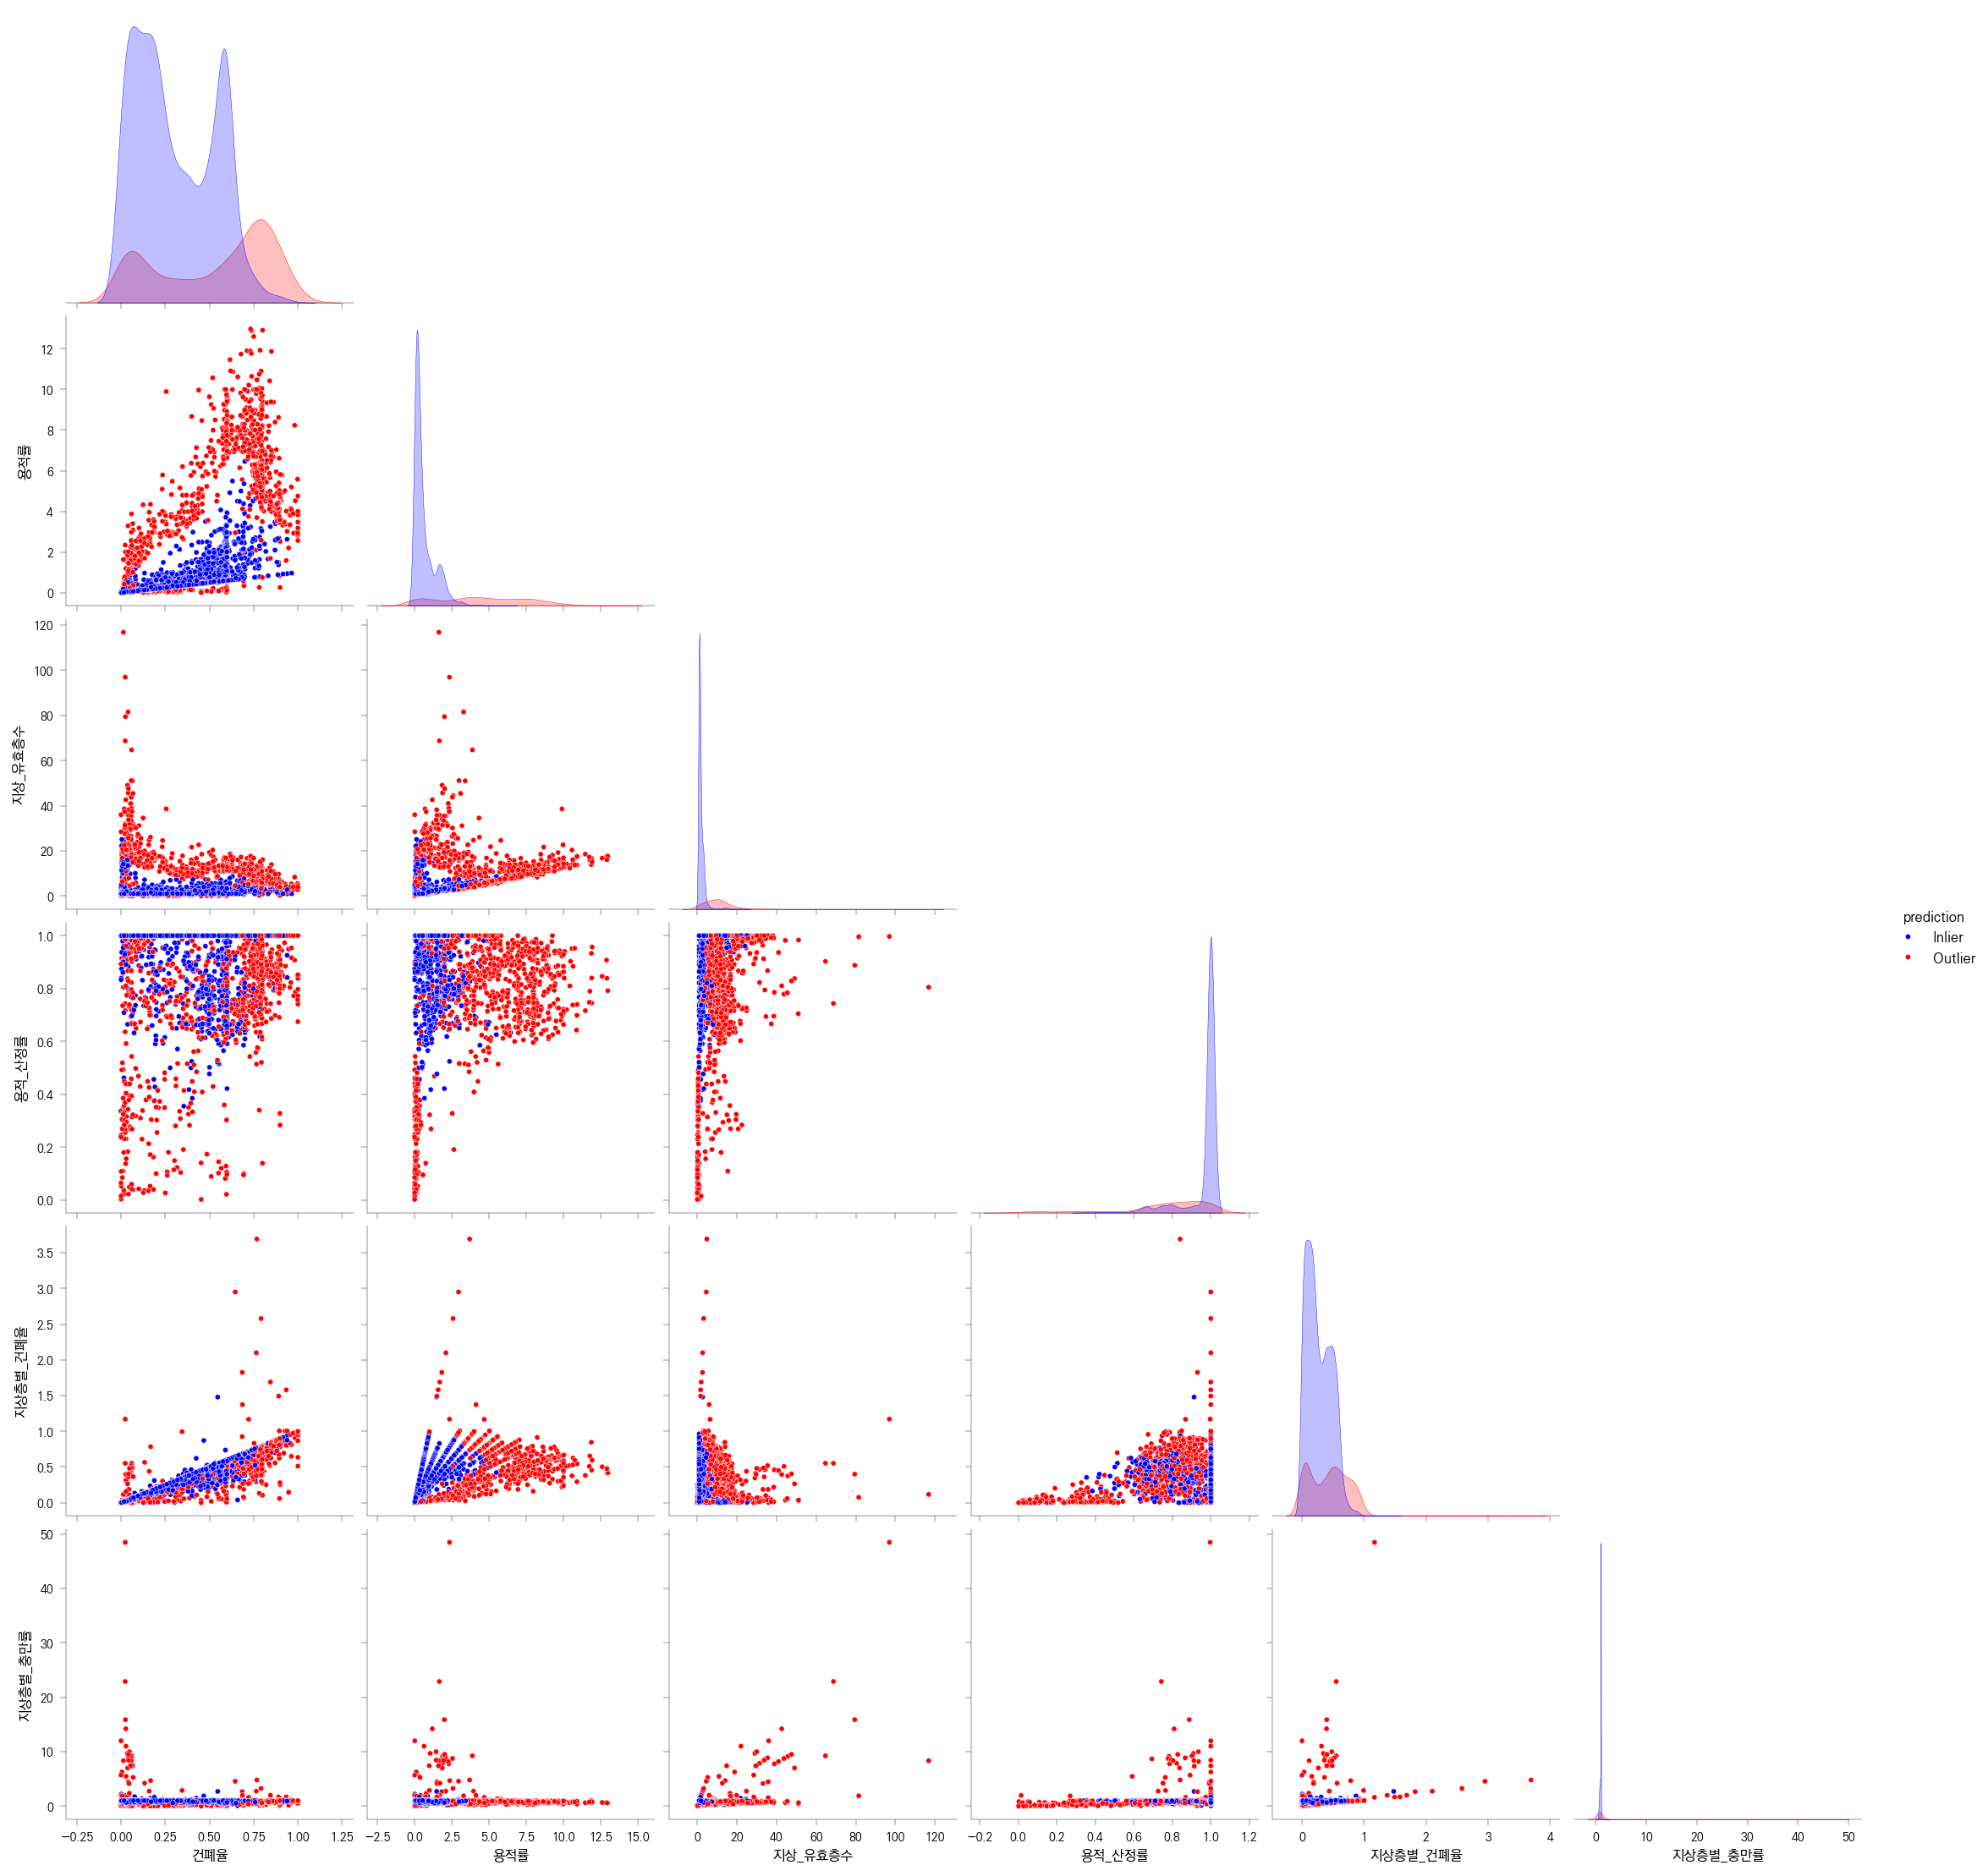

In [28]:
sns.pairplot(
    plot_df, hue="prediction", corner=True, palette={"Outlier": "red", "Inlier": "blue"}
)

---

시도별, 연도별 표를 만들어보자.


In [29]:
df_results = df_orig.copy()
df_results["이상값"] = df_dimensionless["pred_both"]
# 무한대/NaN 정리
df_results = df_results.replace([np.nan, pd.NA, float("inf"), -float("inf")], pd.NA)
df_results["시도_코드"] = df_results["시군구_코드"].str[:2]
df_results["사용승인_년"] = df_results["사용승인_일"].str[:4]
df_results = df_results[
    [
        "관리_건축물대장_PK",
        "시도_코드",
        "사용승인_년",
        "주_용도_코드",
        "기존14",
        "기존16",
        "기존19",
        "기존20",
        "신규01",
        "신규02",
        "이상값",
    ]
]
with pd.option_context("display.max_columns", None):
    print(tabulate(df_results.head(30), headers="keys", tablefmt="psql"))

+----+----------------------+-------------+---------------+----------------+----------+----------+----------+----------+----------+----------+----------+
|    |   관리_건축물대장_PK |   시도_코드 | 사용승인_년   |   주_용도_코드 | 기존14   | 기존16   | 기존19   | 기존20   | 신규01   | 신규02   | 이상값   |
|----+----------------------+-------------+---------------+----------------+----------+----------+----------+----------+----------+----------+----------|
|  0 |             10021950 |          11 | <NA>          |          01000 | <NA>     | <NA>     | <NA>     | <NA>     | <NA>     | <NA>     | <NA>     |
|  1 |             10021957 |          11 | 2000          |          02000 | False    | False    | False    | True     | False    | False    | False    |
|  2 |             10021958 |          11 | 1976          |          02000 | <NA>     | <NA>     | <NA>     | <NA>     | <NA>     | <NA>     | <NA>     |
|  3 |             10021973 |          11 | 1969          |          04000 | <NA>     | <NA>     | <NA>     | <N

In [30]:
df_results.to_parquet("../results/area_data_anomaly.parquet", index=False)